# Panoramic-Stitching Method Comparison

Compares eight outlier-removal / warping methods for panoramic stitching on a
synthetic ground-truth protocol (docx `method_comparison_package.docx`, Sec 6.1):
a real photo, a known random homography, composed with a smooth non-homographic
bump+vortex perturbation field, so the true pixel-level warp is known exactly
everywhere.

Methods 1-2 are classical global-homography baselines (RANSAC, MAGSAC++).
Method 3 is the base paper's own pipeline (relative-attribute filter + global
homography, no RANSAC). Methods 4-6 are local-warp baselines (CPW-style grid,
APAP/Moving-DLT, Li/Tang-style Delaunay-with-prior) with the base paper's
RANSAC-free relative-attribute filter substituted in for a fair comparison
(docx Sec 4, 7.3). Methods 7-8 are our method: Delaunay mesh, data+ASAP, no
global-homography term, rendered with plain barycentric interpolation (7) or
Hermite/Jacobian-enriched interpolation (8).

Running this notebook top-to-bottom regenerates everything in `results/` from
scratch.

## 1. Setup / imports

In [1]:
import sys, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import data
import evaluate
import method_ransac
import method_magsac
import method_base_paper
import method_cpw
import method_apap
import method_li_tang
import method_ours_barycentric
import method_ours_hermite

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

# Seeds and the method list are the only things you need to touch to extend
# this comparison -- everything below is driven off these two constants.
SEEDS = list(range(10))
REPRESENTATIVE_SEED = SEEDS[0]

METHODS = [
    ("RANSAC + global H", method_ransac),
    ("MAGSAC++ + global H", method_magsac),
    ("Base paper (hist filter + global H)", method_base_paper),
    ("CPW-style (grid + H-prior)", method_cpw),
    ("APAP / Moving-DLT", method_apap),
    ("Li/Tang-style (Delaunay + H-prior)", method_li_tang),
    ("Ours: Delaunay, barycentric", method_ours_barycentric),
    ("Ours: Delaunay, Hermite (best)", method_ours_hermite),
]
METHOD_NAMES = [name for name, _ in METHODS]
print(f"{len(METHODS)} methods x {len(SEEDS)} seeds")

8 methods x 10 seeds


## 2. Data generation (synthetic ground truth, docx Sec 6.1)

Each seed picks a different bundled real photo, applies a random homography,
and composes a bump+vortex perturbation on top. Preview one pair before
running the full comparison.

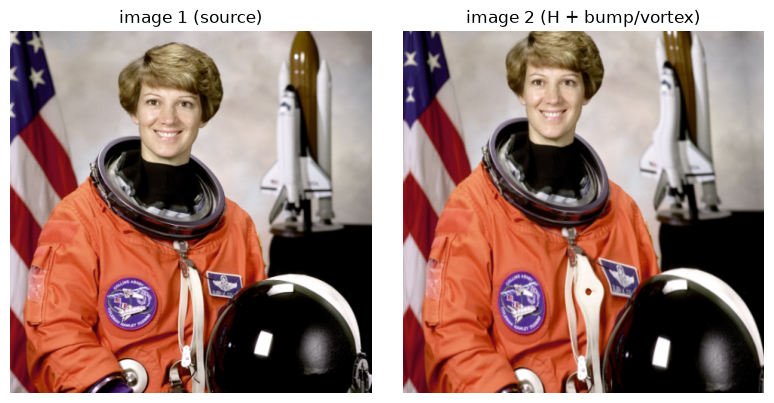

ground-truth homography:
 [[ 8.50600e-01 -6.90000e-03  1.05187e+01]
 [-3.61000e-02  9.51800e-01 -1.76804e+01]
 [-1.00000e-04 -2.00000e-04  1.00000e+00]]
perturbation field params: {'center_bump': array([250.47, 344.42]), 'amp_bump': np.float64(12.53), 'sigma_bump': np.float64(57.77), 'center_vortex': array([325.78, 128.06]), 'amp_vortex': np.float64(8.38), 'sigma_vortex': np.float64(68.56)}


In [2]:
preview_pair = data.make_synthetic_pair(REPRESENTATIVE_SEED)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(preview_pair.img1[..., ::-1]); axes[0].set_title("image 1 (source)"); axes[0].axis("off")
axes[1].imshow(preview_pair.img2[..., ::-1]); axes[1].set_title("image 2 (H + bump/vortex)"); axes[1].axis("off")
plt.tight_layout(); plt.show()

print("ground-truth homography:\n", np.round(preview_pair.H, 4))
print("perturbation field params:", {k: (np.round(v, 2) if hasattr(v, "__len__") or isinstance(v, float) else v)
                                       for k, v in preview_pair.field_params.items()})

## 3. Run all methods across seeds

Every method receives the exact same SIFT detections and the exact same raw
match set for a given seed (an 80/20 used/held-out split of the raw matches,
docx Sec 7.3 fairness checklist); each method does its own outlier removal
internally. Only the outlier-removal-through-warp-estimation stage is timed
(SIFT detection/matching is shared and excluded, docx Sec 6.3).

In [3]:
t0 = time.perf_counter()
long_df, seed_cache = evaluate.run_comparison(METHODS, SEEDS)
print(f"Ran {len(METHODS)} methods x {len(SEEDS)} seeds in {time.perf_counter() - t0:.1f}s")
long_df.to_csv(RESULTS_DIR / "per_seed_results.csv", index=False)
long_df.head(10)

Ran 8 methods x 10 seeds in 7.8s


,geo_err_heldout,geo_err_dense,geo_err_near_pert,geo_err_corners,mge,time_ms,num_inverted_triangles,num_inliers,seed,method
0,2.520573,4.136455,6.816753,9.238286,14.748569,1.312010,NaN,322,0,RANSAC + global H
1,2.196527,2.310373,6.071691,1.812235,10.417928,0.694935,NaN,340,0,MAGSAC++ + global H
2,2.455062,2.793177,6.229225,3.366481,11.608155,6.755299,NaN,329,0,Base paper (hist filter + global H)
3,6.055080,7.911258,8.955316,14.141686,22.703516,11.302000,0.0,329,0,CPW-style (grid + H-prior)
4,1.273914,1.942282,4.665262,2.617755,7.664329,422.749575,NaN,329,0,APAP / Moving-DLT
5,3.290218,7.149455,7.040467,22.605334,18.442680,23.511687,0.0,329,0,Li/Tang-style (Delaunay + H-prior)
6,3.478975,8.067764,7.422848,25.736530,19.674879,11.504484,1.0,329,0,"Ours: Delaunay, barycentric"
7,3.299614,7.854773,7.746287,25.736530,19.569902,10.116399,1.0,329,0,"Ours: Delaunay, Hermite (best)"
8,1.983743,3.188348,5.918340,1.423025,10.089499,0.698100,NaN,214,1,RANSAC + global H
9,2.085913,3.353914,5.974766,2.098838,10.181788,0.464887,NaN,220,1,MAGSAC++ + global H


## 4. Metrics table (method x metric, averaged across seeds with std dev)

Held-out matches, dense random points, near-perturbation points, and the 4
corners (docx Sec 6.2), each scored by mean geometric error against the known
synthetic ground truth; plus MGE (pixel-intensity agreement in the overlap
region), timing, and inverted-triangle counts for mesh methods (docx Sec 6.3).

In [4]:
summary = evaluate.summarize(long_df)
csv_path = RESULTS_DIR / "comparison_table.csv"
summary.to_csv(csv_path)
print(f"Wrote {csv_path}")

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
summary.round(3)

Wrote results/comparison_table.csv


,geo_err_heldout_mean,geo_err_heldout_std,geo_err_dense_mean,geo_err_dense_std,geo_err_near_pert_mean,geo_err_near_pert_std,geo_err_corners_mean,geo_err_corners_std,mge_mean,mge_std,time_ms_mean,time_ms_std,num_inverted_triangles_mean,num_inverted_triangles_std,num_inliers_mean,num_inliers_std
method,,,,,,,,,,,,,,,,
APAP / Moving-DLT,1.708,1.063,3.547,2.768,5.457,2.274,6.199,5.806,6.896,2.734,164.901,119.155,NaN,NaN,185.7,118.989
Base paper (hist filter + global H),2.831,0.832,4.482,2.357,6.861,1.818,7.174,5.426,9.678,2.481,3.202,2.043,NaN,NaN,185.7,118.989
CPW-style (grid + H-prior),5.405,1.192,6.830,1.972,7.848,1.686,11.357,3.357,14.381,5.060,6.615,2.057,0.0,0.000,185.7,118.989
Li/Tang-style (Delaunay + H-prior),3.050,1.279,5.907,2.574,6.725,1.839,14.231,6.550,11.276,3.919,12.272,5.929,0.3,0.675,185.7,118.989
MAGSAC++ + global H,2.518,0.703,3.473,1.205,6.120,0.977,5.152,3.592,8.463,1.786,0.592,0.162,NaN,NaN,222.1,94.906
"Ours: Delaunay, Hermite (best)",3.430,1.617,7.145,3.369,7.177,2.348,16.325,7.496,12.181,4.247,9.187,2.933,0.4,0.699,185.7,118.989
"Ours: Delaunay, barycentric",3.515,1.679,6.962,3.456,7.028,2.193,16.325,7.496,12.178,4.502,9.492,3.034,0.4,0.699,185.7,118.989
RANSAC + global H,2.954,1.197,4.595,2.666,7.069,2.237,7.145,6.471,9.713,3.115,0.955,0.697,NaN,NaN,211.1,91.235


In [5]:
display_cols = ["geo_err_heldout_mean", "geo_err_dense_mean", "geo_err_near_pert_mean",
                "geo_err_corners_mean", "mge_mean", "time_ms_mean",
                "num_inverted_triangles_mean", "num_inliers_mean"]
summary[display_cols].round(2)

,geo_err_heldout_mean,geo_err_dense_mean,geo_err_near_pert_mean,geo_err_corners_mean,mge_mean,time_ms_mean,num_inverted_triangles_mean,num_inliers_mean
method,,,,,,,,
APAP / Moving-DLT,1.71,3.55,5.46,6.20,6.90,164.90,NaN,185.7
Base paper (hist filter + global H),2.83,4.48,6.86,7.17,9.68,3.20,NaN,185.7
CPW-style (grid + H-prior),5.40,6.83,7.85,11.36,14.38,6.61,0.0,185.7
Li/Tang-style (Delaunay + H-prior),3.05,5.91,6.72,14.23,11.28,12.27,0.3,185.7
MAGSAC++ + global H,2.52,3.47,6.12,5.15,8.46,0.59,NaN,222.1
"Ours: Delaunay, Hermite (best)",3.43,7.14,7.18,16.32,12.18,9.19,0.4,185.7
"Ours: Delaunay, barycentric",3.52,6.96,7.03,16.32,12.18,9.49,0.4,185.7
RANSAC + global H,2.95,4.60,7.07,7.15,9.71,0.96,NaN,211.1


## 5. Comparison figures (representative seed)

Grid of all 8 methods' warps + target image + per-pixel error heatmap, for
`REPRESENTATIVE_SEED`.

Wrote results/comparison_grid.png


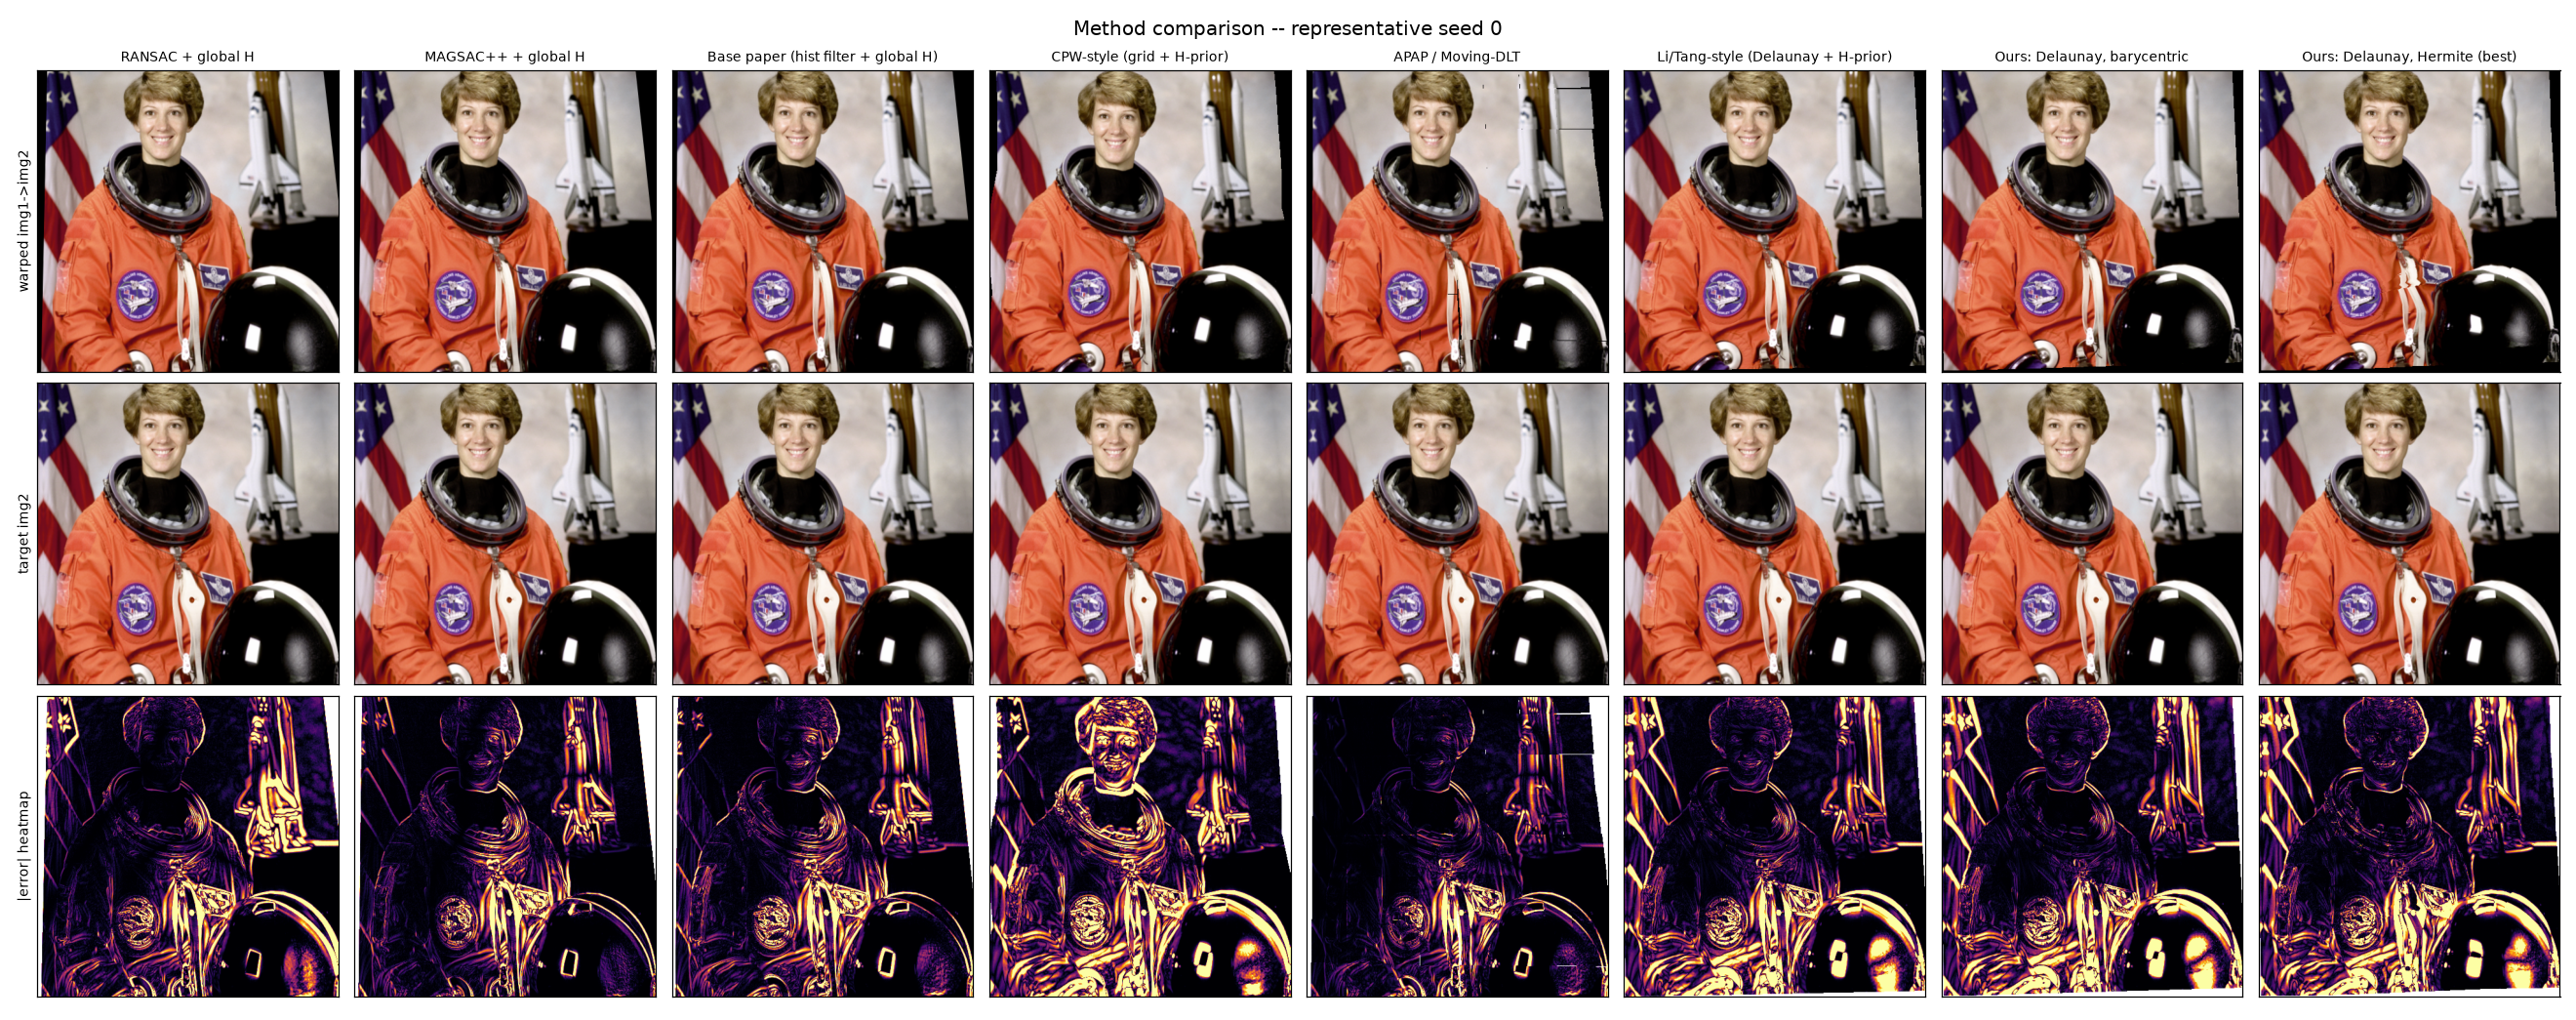

In [6]:
figure_path = RESULTS_DIR / "comparison_grid.png"
evaluate.plot_comparison_grid(seed_cache[REPRESENTATIVE_SEED], METHOD_NAMES, str(figure_path))
print(f"Wrote {figure_path}")

from IPython.display import Image, display
display(Image(filename=str(figure_path)))

## 6. Sanity checks + results/README.md

Don't just dump numbers -- flag anything that looks off (docx-requested sanity
check): numerically unstable seeds, timing that doesn't match the docx's
complexity claims, degenerate low-inlier runs, inverted triangles.

In [7]:
degenerate = long_df[long_df["num_inliers"] < 8]
if len(degenerate):
    print("Low-inlier (< 8) runs -- check these seeds/methods for instability:")
    display(degenerate[["seed", "method", "num_inliers", "geo_err_dense"]])
else:
    print("No pathologically low-inlier runs across these seeds.")

print()
print("Inverted triangles by method (sum across seeds):")
print(long_df.groupby("method")["num_inverted_triangles"].sum(min_count=1))

print()
print("Timing sanity (mean ms, outlier-removal + warp-estimation stage only):")
print(summary["time_ms_mean"].sort_values())

No pathologically low-inlier runs across these seeds.

Inverted triangles by method (sum across seeds):
method
APAP / Moving-DLT                      NaN
Base paper (hist filter + global H)    NaN
CPW-style (grid + H-prior)             0.0
Li/Tang-style (Delaunay + H-prior)     3.0
MAGSAC++ + global H                    NaN
Ours: Delaunay, Hermite (best)         4.0
Ours: Delaunay, barycentric            4.0
RANSAC + global H                      NaN
Name: num_inverted_triangles, dtype: float64

Timing sanity (mean ms, outlier-removal + warp-estimation stage only):
method
MAGSAC++ + global H                      0.592187
RANSAC + global H                        0.955303
Base paper (hist filter + global H)      3.201869
CPW-style (grid + H-prior)               6.614624
Ours: Delaunay, Hermite (best)           9.187343
Ours: Delaunay, barycentric              9.492382
Li/Tang-style (Delaunay + H-prior)      12.271616
APAP / Moving-DLT                      164.900915
Name: time_ms_mean, d

In [8]:
readme_path = RESULTS_DIR / "README.md"
evaluate.write_results_readme(summary, long_df, SEEDS, str(readme_path),
                               csv_name="comparison_table.csv", figure_name="comparison_grid.png")
print(f"Wrote {readme_path}\n")
print(readme_path.read_text())

Wrote results/README.md

# Results summary

Averaged over 10 synthetic seeds (0-9), see `comparison_table.csv` for the full method x metric table (mean +/- std) and `comparison_grid.png` for a representative-seed render of every method's warp plus its pixel-error heatmap.

On dense random query points, **MAGSAC++ + global H** has the lowest mean geometric error (3.47px) and **Ours: Delaunay, Hermite (best)** the highest (7.14px); **MAGSAC++ + global H** is the fastest outlier-removal-plus-warp-estimation stage (0.59ms) and **APAP / Moving-DLT** the slowest (164.90ms), which matches APAP's O(grid_cells x matches) weighted-DLT-per-cell cost against RANSAC/MAGSAC's native OpenCV implementations and the O(N) single sparse solve of the mesh methods.

Flag: all Delaunay/grid mesh methods extrapolate poorly at the 4 image corners by construction (no data term reaches them, docx Sec 6.2) -- their mean corner error is 2.3x the global-homography methods' corner error on average, which is expecte